First 5 rows:
   order_id                    order_date    city     product     category  \
0      1001 1970-01-01 00:00:00.000045667    Pune      Laptop  Electronics   
1      1002 1970-01-01 00:00:00.000045668  Mumbai      Mobile  Electronics   
2      1003 1970-01-01 00:00:00.000045668    Pune  Headphones  Accessories   
3      1004 1970-01-01 00:00:00.000045669  Nagpur    Keyboard  Accessories   
4      1005 1970-01-01 00:00:00.000045670  Mumbai      Laptop  Electronics   

   quantity  price  total_sales  
0         2  50000       100000  
1         3  20000        60000  
2         5   2000        10000  
3         4   1500         6000  
4         1  50000        50000  

Info:
<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     55 non-null     int64         
 1   order_date   55 non-null     datetime64[ns]
 2   city         5

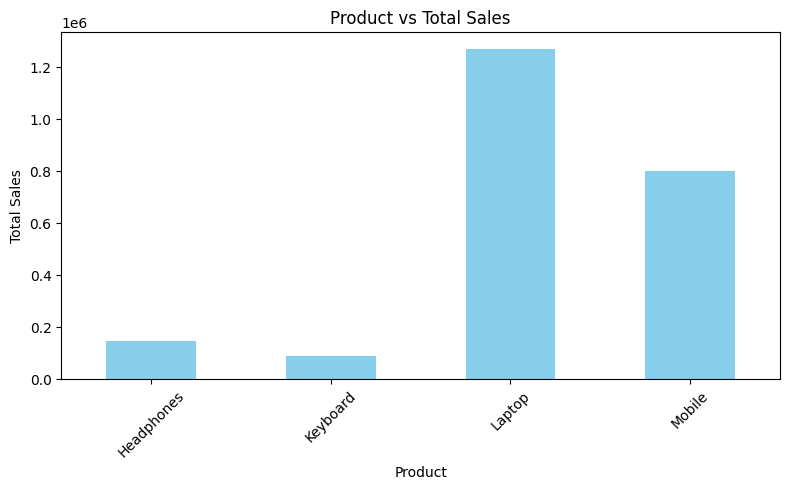

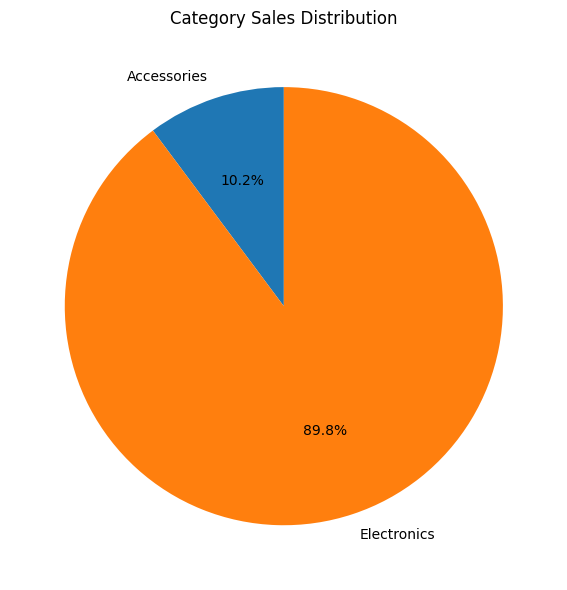

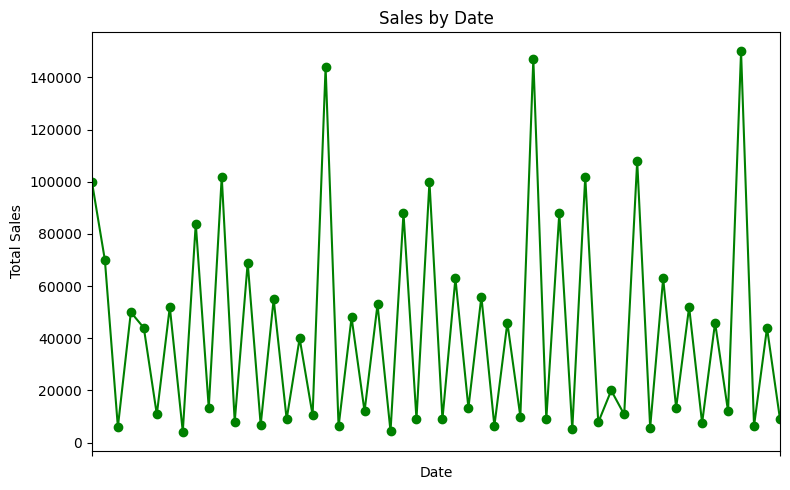

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data.csv")

# Convert date column
df["order_date"] = pd.to_datetime(df["order_date"])

# Create total_sales column
df["total_sales"] = df["quantity"] * df["price"]

print("First 5 rows:")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

# Total Revenue
total_revenue = df["total_sales"].sum()
print("\nTotal Revenue:", total_revenue)

# Most Sold Product
most_sold_product = df.groupby("product")["quantity"].sum().idxmax()
print("Most Sold Product:", most_sold_product)

# Sales by City
sales_by_city = df.groupby("city")["total_sales"].sum()
print("\nSales by City:")
print(sales_by_city)

# Summary Statistics
print("\nSummary Statistics:")
print(df[["quantity", "price", "total_sales"]].describe())

# 1) Product vs Total Sales (Bar Chart)
product_sales = df.groupby("product")["total_sales"].sum()
plt.figure(figsize=(8, 5))
product_sales.plot(kind="bar", color="skyblue")
plt.title("Product vs Total Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2) Category Sales Distribution (Pie Chart)
category_sales = df.groupby("category")["total_sales"].sum()
plt.figure(figsize=(6, 6))
category_sales.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Category Sales Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 3) Sales by Date (Line Chart)
sales_by_date = df.groupby("order_date")["total_sales"].sum()
plt.figure(figsize=(8, 5))
sales_by_date.plot(kind="line", marker="o", color="green")
plt.title("Sales by Date")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()